In [5]:
# importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
# reding the given csv file into pandas dataframe
trader_df =pd.read_csv('../data/historical_data.csv')
sentiment_df = pd.read_csv('../data/fear_greed_index.csv')

In [7]:
# displaying the first 5 rows of the trader dataframe
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
# displaying the first 5 rows of the sentiment dataframe
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
# checking the shape of the trader dataframe
trader_df.shape

(211224, 16)

In [10]:
# checking the shape of the sentiment dataframe
sentiment_df.shape

(2644, 4)

In [11]:
# checking the columns of the trader dataframe
trader_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [12]:
# checking the columns of the sentiment dataframe
sentiment_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [13]:
# checking the info of the trader dataframe
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [14]:
# checking the info of the sentiment dataframe
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [15]:
# checking the null values in the trader dataframe
trader_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [16]:
# checking the null values in the sentiment dataframe
sentiment_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [17]:
# converting the 'Timestamp IST' column to datetime format(converting string date into datetime object) )
trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [18]:
# converting the 'date' column to datetime format(converting string date into datetime object) )
sentiment_df['date']=pd.to_datetime(sentiment_df['date'])

In [19]:
# extracting the date from the 'Timestamp IST' column and creating a new column 'date' in the trader dataframe
# .dt.date is used to extract the date from the datetime object
trader_df['date']=trader_df['Timestamp IST'].dt.date

In [20]:
# doing this to make the date column in both dataframes in the same format so that we can merge them later on
sentiment_df['date']= sentiment_df['date'].dt.date

In [21]:
# checking the duplicated values in the trader dataframe (or checking how many duplicated values are there in the trader  dataframe )
trader_df.duplicated().sum()    

np.int64(0)

In [22]:
# same for the sentiment dataframe(for checking how many duplicated values are there in the sentiment dataframe )
sentiment_df.duplicated().sum()

np.int64(0)

In [23]:
# checking the unique values in the 'classification' column of the sentiment dataframe
sentiment_df['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [24]:
# merging the trader dataframe and the sentiment dataframe on the 'date' column using left join
# on='date' here is use to match rows where dates are same 
# how='left' here is used to keep all the rows from the trader dataframe and only the matching rows from the sentiment dataframe (if there is no match in the sentiment dataframe, it will fill with NaN)
merged_df=pd.merge(
    trader_df,
    sentiment_df,
    on='date',
    how='left'
)

In [25]:
# for behavioral analysis 
merged_df[['Coin','Closed PnL', 'classification']].head()

,Coin,Closed PnL,classification
0,@107,0.0,Extreme Greed
1,@107,0.0,Extreme Greed
2,@107,0.0,Extreme Greed
3,@107,0.0,Extreme Greed
4,@107,0.0,Extreme Greed


In [26]:
# for profitability analysis
# filtering the merged dataframe to get only the rows where the 'Closed PnL' is not equal to 0 (or filtering the rows where the profit is not equal to 0)
profit_df = merged_df[
    merged_df['Closed PnL'] != 0
]

In [27]:
# to understand which emotions/sentiment dominate the market activity 
merged_df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

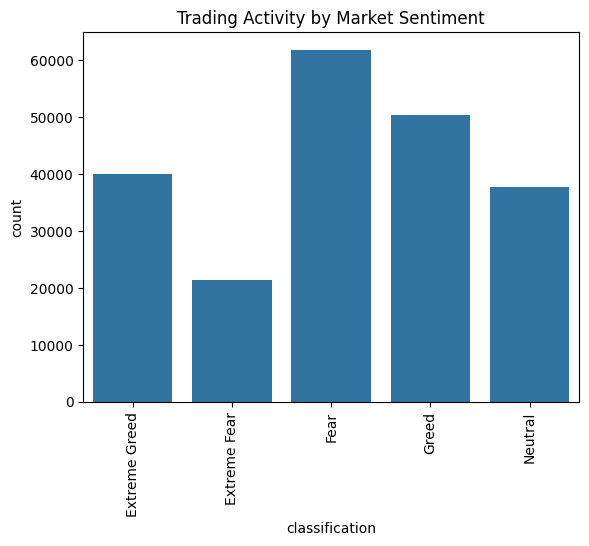

In [64]:
# visualizing the trading activity by market sentiment using countplot (or visualizing the count of each sentiment in the merged dataframe)
sns.countplot(
    data=merged_df,
    x='classification'
)

plt.xticks(rotation=90)
plt.title("Trading Activity by Market Sentiment")

plt.show()

In [31]:
# analyzing the average profit/loss for each sentiment category )  
profit_df.groupby(
    'classification'
)['Closed PnL'].mean()

classification
Extreme Fear      71.027316
Extreme Greed    130.205309
Fear             112.625988
Greed             85.403927
Neutral           71.199993
Name: Closed PnL, dtype: float64

In [32]:
# trading data has some outliers, so analyzing the median profit/loss for each sentiment category to get a better understanding of the central tendency of the profit/loss distribution for each sentiment category
profit_df.groupby(
    'classification'
)['Closed PnL'].median()

classification
Extreme Fear     6.388050
Extreme Greed    8.530740
Fear             6.350483
Greed            4.927600
Neutral          4.583458
Name: Closed PnL, dtype: float64

In [33]:
# standard deviation of profit/loss for each sentiment category to understand the variability of the profit/loss distribution for each sentiment category
profit_df.groupby(
    'classification'
)['Closed PnL'].std()

classification
Extreme Fear     1628.408341
Extreme Greed    1058.126139
Fear             1344.778427
Greed            1576.394764
Neutral           743.212863
Name: Closed PnL, dtype: float64

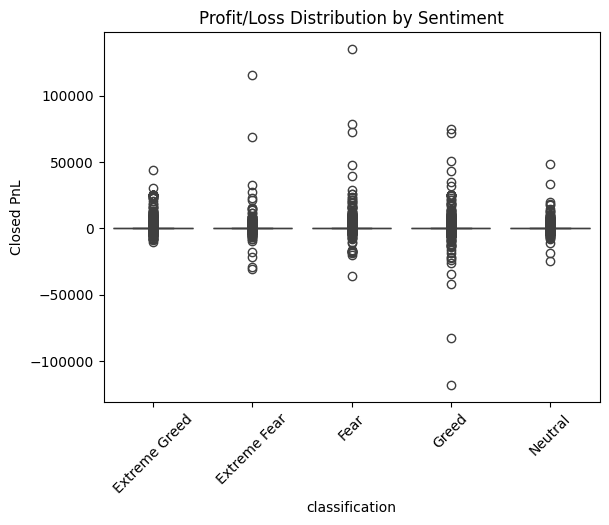

In [34]:
# using boxplot to visualize the profit/loss distribution for each sentiment category to understand the spread and outliers in the profit/loss distribution for each sentiment category
sns.boxplot(
    data=profit_df,
    x='classification',
    y='Closed PnL'
)

plt.xticks(rotation=45)

plt.title("Profit/Loss Distribution by Sentiment")

plt.show()

In [39]:
# analyzing the average trade size for each sentiment category to understand if there is any relationship between trade size and market sentiment
merged_df.groupby(
    'classification'    
)['Size USD' ].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

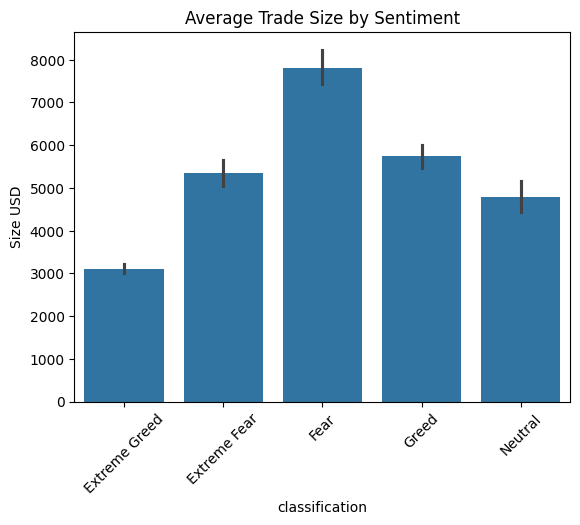

In [40]:
# visualizing the average trade size for each sentiment category using barplot to understand if there is any relationship between trade size and market sentiment
sns.barplot(   
    data=merged_df,
    x='classification',
    y='Size USD'
)   
plt.xticks(rotation=45)
plt.title("Average Trade Size by Sentiment")
plt.show()

In [42]:
# analyzing the relationship between market sentiment and trade direction (long or short) using crosstab to understand if there is any relationship between market sentiment and trade direction
pd.crosstab(
    merged_df['classification'],
    merged_df['Side']
)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


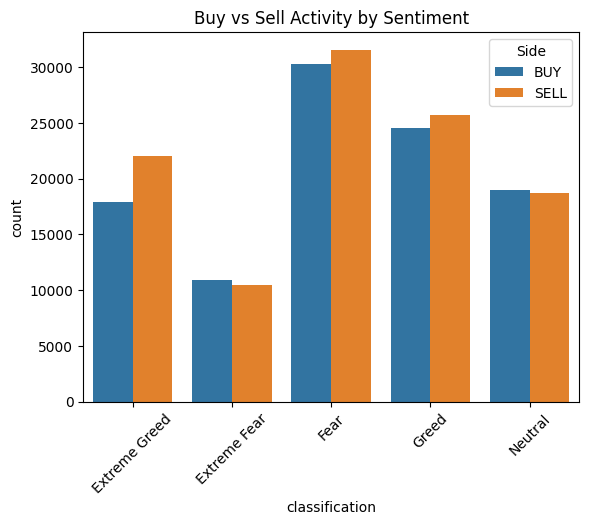

In [43]:
sns.countplot(
    data=merged_df,
    x='classification',
    hue='Side'
)

plt.xticks(rotation=45)

plt.title("Buy vs Sell Activity by Sentiment")

plt.show()

In [59]:
# this is to analyze the relationship between market sentiment and trade direction (long or short) using crosstab to understand if there is any relationship between market sentiment and trade direction
pd.crosstab(
    merged_df['classification'],
    merged_df['Direction']
)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


In [45]:
# analyzing the most traded coins in the dataset to understand which coins are more popular among traders
merged_df['Coin'].value_counts().head(10)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

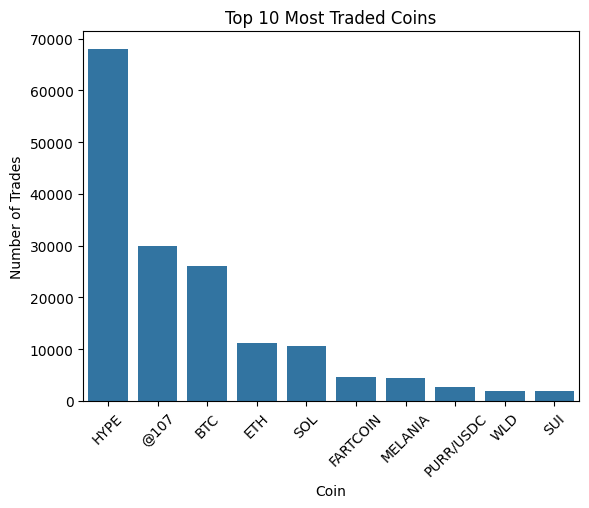

In [46]:
top_coins = merged_df['Coin'].value_counts().head(10)

sns.barplot(
    x=top_coins.index,
    y=top_coins.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Most Traded Coins")

plt.xlabel("Coin")
plt.ylabel("Number of Trades")

plt.show()


In [47]:
# analyzing the average profit/loss for each coin to understand which coins are more profitable for traders
coin_profit = profit_df.groupby(
    'Coin'
)['Closed PnL'].mean().sort_values(ascending=False).head(10)

coin_profit

Coin
EIGEN     663.580126
ENA       654.606938
@85       616.421861
AVAX      459.974418
@109      386.720296
PEOPLE    360.646005
ETHFI     354.266178
SOL       325.955453
DOGE      321.444785
@59       319.638201
Name: Closed PnL, dtype: float64

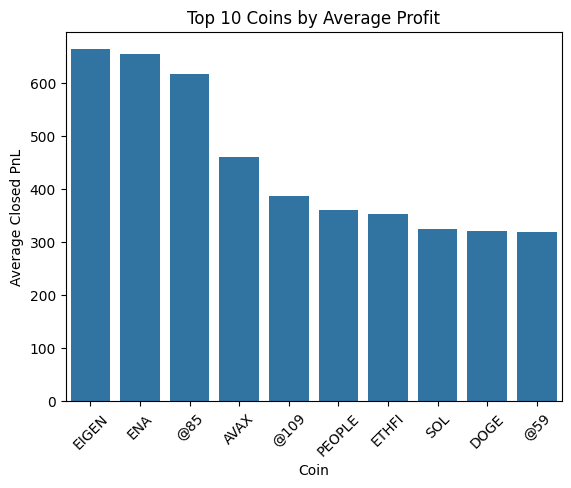

In [49]:
# visualizing the average profit/loss for the top 10 coins using barplot to understand which coins are more profitable for traders
sns.barplot(
    x=coin_profit.index,
    y=coin_profit.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Coins by Average Profit")

plt.xlabel("Coin")
plt.ylabel("Average Closed PnL")

plt.show()

In [51]:
# measures which coins have most unstable outcomes in terms of profit/loss by calculating the standard deviation of profit/loss for each coin and sorting them in descending order to get the top 10 most volatile coins
coin_volatility = profit_df.groupby(
    'Coin'
)['Closed PnL'].std().sort_values(ascending=False).head(10)

coin_volatility

Coin
ETH      4001.450351
TRUMP    3550.070513
DOGE     2671.413021
EIGEN    2247.244144
SOL      2061.711189
ENA      2028.832064
AVAX     1405.915201
@107     1338.990735
LAYER    1314.858077
ARB      1289.755146
Name: Closed PnL, dtype: float64

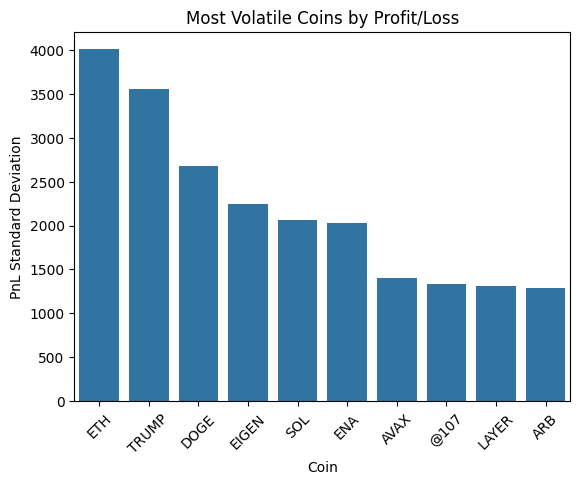

In [52]:
sns.barplot(
    x=coin_volatility.index,
    y=coin_volatility.values
)

plt.xticks(rotation=45)

plt.title("Most Volatile Coins by Profit/Loss")

plt.xlabel("Coin")
plt.ylabel("PnL Standard Deviation")

plt.show()

In [54]:
#to understand which traders are more profitable by calculating the total profit/loss for each trader and sorting them in descending order to get the top 10 most profitable traders
top_traders = profit_df.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(ascending=False).head(10)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

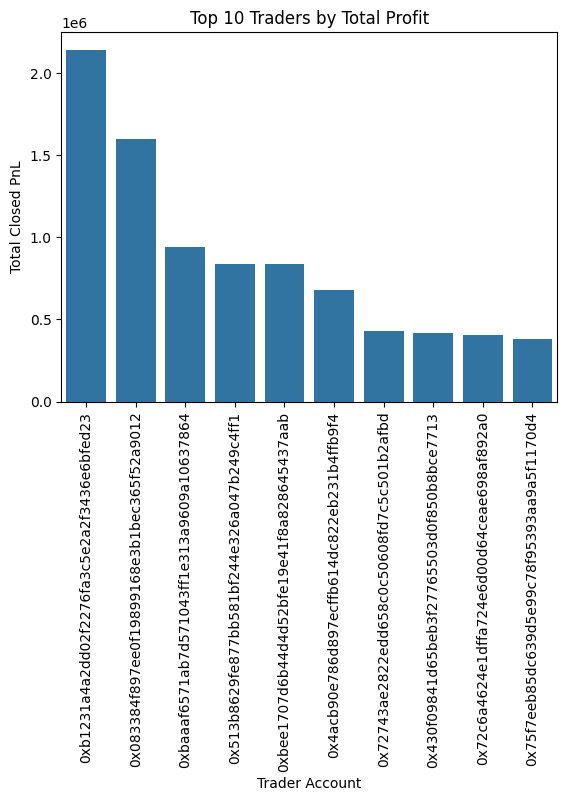

In [55]:
sns.barplot(
    x=top_traders.index,
    y=top_traders.values
)

plt.xticks(rotation=90)

plt.title("Top 10 Traders by Total Profit")

plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")

plt.show()

In [56]:
# who trades the most by counting the number of trades for each trader and sorting them in descending order to get the top 10 most active traders
active_traders = merged_df['Account'].value_counts().head(10)
active_traders

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
Name: count, dtype: int64

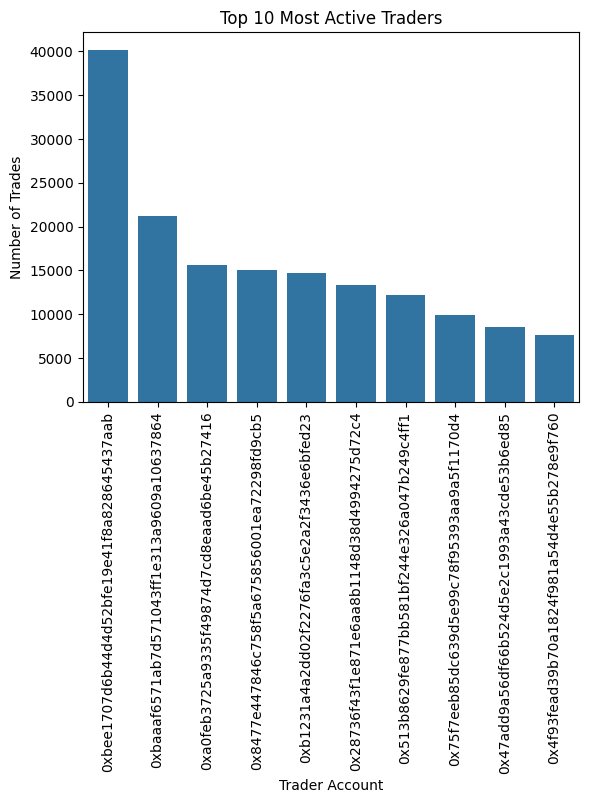

In [57]:
sns.barplot(
    x=active_traders.index,
    y=active_traders.values
)

plt.xticks(rotation=90)

plt.title("Top 10 Most Active Traders")

plt.xlabel("Trader Account")
plt.ylabel("Number of Trades")

plt.show()

In [58]:
# average profit/loss for the top 10 most active traders to understand if there is any relationship between trading activity and profitability
avg_profit = profit_df.groupby(
    'Account'
)['Closed PnL'].mean().sort_values(ascending=False).head(10)

avg_profit

Account
0x420ab45e0bd8863569a5efbb9c05d91f40624641    2216.728808
0x083384f897ee0f19899168e3b1bec365f52a9012     923.920219
0x72c6a4624e1dffa724e6d00d64ceae698af892a0     714.559405
0x430f09841d65beb3f27765503d0f850b8bce7713     695.395446
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     582.572003
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     341.357318
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     338.583843
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     303.514129
0xae5eacaf9c6b9111fd53034a602c192a04e082ed     294.980954
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0     285.672487
Name: Closed PnL, dtype: float64